# Bond Basics

Bonds are debt instruments. Instead of buying ownership in a company, the investor lends money and receives contractual cash flows: usually periodic coupons plus repayment of principal at maturity.

Abbreviations used in this notebook:

- **FV**: Face Value, also called par value or principal.
- **YTM**: Yield to Maturity, the discount rate that equates a bond's cash flows with its price.
- **AI**: Accrued Interest, coupon interest earned since the last coupon date.
- **PV**: Present Value, today's value of future cash flows.
- **CHF**: Swiss franc, the currency used in the examples.

## 1. Intuition

A bond price is the present value of future debt cash flows. The investor pays today, receives coupon payments during the bond's life, and receives the face value at maturity.

Key bond concepts:

- **Face value**: principal amount repaid at maturity, often quoted as 100.
- **Coupon rate**: annual interest rate paid on face value.
- **Coupon frequency**: number of coupon payments per year.
- **Maturity**: date when principal is repaid.
- **Yield**: return implied by the bond's price and promised cash flows.
- **Clean price**: quoted bond price, excluding accrued interest.
- **Dirty price**: settlement price, including accrued interest.
- **Accrued interest**: interest earned by the seller since the last coupon date.
- **Duration**: sensitivity of the bond price to changes in yield.
- **Credit spread**: extra yield over a safer reference rate for bearing credit risk.

> Bond prices and yields move in opposite directions. When required yield rises, the present value of fixed future coupons falls. When required yield falls, the present value rises.

## 2. Mathematics

**Coupon payment per period:**

$$
C = \frac{\text{Coupon Rate} \times FV}{m}
$$

Where:

- $C$ = coupon payment per period
- $FV$ = face value
- $m$ = coupon payments per year

**Bond price as present value of cash flows:**

$$
P = \sum_{t=1}^{N} \frac{C}{\left(1 + \frac{y}{m}\right)^t} + \frac{FV}{\left(1 + \frac{y}{m}\right)^N}
$$

Where:

- $P$ = bond price
- $C$ = coupon payment per period
- $y$ = annual yield to maturity
- $m$ = coupon payments per year
- $N$ = total remaining coupon periods
- $FV$ = face value repaid at maturity

**Accrued interest:**

$$
AI = C \times \frac{\text{Days Since Last Coupon}}{\text{Days in Coupon Period}}
$$

Where:

- $AI$ = accrued interest
- $C$ = coupon payment per period
- day count depends on the bond's market convention

**Dirty price:**

$$
\text{Dirty Price} = \text{Clean Price} + \text{Accrued Interest}
$$

The clean price is usually the quoted price. The dirty price is the amount paid at settlement because the buyer compensates the seller for interest earned since the last coupon date.

**Approximate modified duration:**

$$
\text{Modified Duration} \approx \frac{P_{-} - P_{+}}{2 \times P_0 \times \Delta y}
$$

Where:

- $P_-$ = bond price when yield decreases by $\Delta y$
- $P_+$ = bond price when yield increases by $\Delta y$
- $P_0$ = current bond price
- $\Delta y$ = yield change expressed as a decimal

## 3. Implementation

We will price a simple fixed-coupon bond, calculate accrued interest, convert clean price to dirty price, and estimate duration. The examples use simplified day-count inputs so the mechanics stay visible.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

In [9]:
face_value = 100.0
coupon_rate = 0.035
yield_to_maturity = 0.041
years_to_maturity = 5
coupon_frequency = 2

periods = years_to_maturity * coupon_frequency
coupon_payment = face_value * coupon_rate / coupon_frequency
periodic_yield = yield_to_maturity / coupon_frequency

cash_flows = np.full(periods, coupon_payment)
cash_flows[-1] += face_value

discount_periods = np.arange(1, periods + 1)
discount_factors = 1 / (1 + periodic_yield) ** discount_periods
present_values = cash_flows * discount_factors

clean_price = present_values.sum()

bond_cash_flows = pd.DataFrame({
    "period": discount_periods,
    "cash_flow": cash_flows,
    "discount_factor": discount_factors,
    "present_value": present_values,
})

print(f"Coupon payment per period: CHF {coupon_payment:,.2f}")
print(f"Clean price: CHF {clean_price:,.2f}")
bond_cash_flows.head()

Coupon payment per period: CHF 1.75
Clean price: CHF 97.31


,period,cash_flow,discount_factor,present_value
0,1,1.7500,0.9799,1.7148
1,2,1.7500,0.9602,1.6804
2,3,1.7500,0.9409,1.6466
3,4,1.7500,0.9220,1.6136
4,5,1.7500,0.9035,1.5811


In [10]:
days_since_last_coupon = 73
days_in_coupon_period = 182

accrued_interest = coupon_payment * days_since_last_coupon / days_in_coupon_period
dirty_price = clean_price + accrued_interest

settlement_summary = pd.DataFrame({
    "metric": [
        "Clean price",
        "Accrued interest",
        "Dirty price",
        "Yield to maturity",
        "Coupon rate",
        "Years to maturity",
    ],
    "value": [
        f"CHF {clean_price:,.2f}",
        f"CHF {accrued_interest:,.2f}",
        f"CHF {dirty_price:,.2f}",
        f"{yield_to_maturity:.2%}",
        f"{coupon_rate:.2%}",
        f"{years_to_maturity} years",
    ],
})

settlement_summary

,metric,value
0,Clean price,CHF 97.31
1,Accrued interest,CHF 0.70
2,Dirty price,CHF 98.01
3,Yield to maturity,4.10%
4,Coupon rate,3.50%
5,Years to maturity,5 years


Yield to maturity is the discount rate that makes the present value of the bond's future cash flows equal to its clean price. In practice, it is solved numerically because the equation usually cannot be rearranged neatly.

In [11]:
def price_fixed_coupon_bond(face_value, coupon_rate, yield_to_maturity, years_to_maturity, coupon_frequency=2):
    periods = int(years_to_maturity * coupon_frequency)
    coupon_payment = face_value * coupon_rate / coupon_frequency
    periodic_yield = yield_to_maturity / coupon_frequency
    cash_flows = np.full(periods, coupon_payment)
    cash_flows[-1] += face_value
    discount_periods = np.arange(1, periods + 1)
    return np.sum(cash_flows / (1 + periodic_yield) ** discount_periods)


def estimate_ytm_bisection(target_price, face_value, coupon_rate, years_to_maturity, coupon_frequency=2):
    low_yield = -0.05
    high_yield = 0.30

    for _ in range(100):
        mid_yield = (low_yield + high_yield) / 2
        mid_price = price_fixed_coupon_bond(
            face_value,
            coupon_rate,
            mid_yield,
            years_to_maturity,
            coupon_frequency,
        )

        if mid_price > target_price:
            low_yield = mid_yield
        else:
            high_yield = mid_yield

    return mid_yield


estimated_ytm = estimate_ytm_bisection(
    clean_price,
    face_value,
    coupon_rate,
    years_to_maturity,
    coupon_frequency,
)

print(f"Estimated YTM from clean price: {estimated_ytm:.2%}")

Estimated YTM from clean price: 4.10%


In [12]:
yield_change = 0.0001

price_down = price_fixed_coupon_bond(face_value, coupon_rate, yield_to_maturity - yield_change, years_to_maturity, coupon_frequency)
price_up = price_fixed_coupon_bond(face_value, coupon_rate, yield_to_maturity + yield_change, years_to_maturity, coupon_frequency)
modified_duration = (price_down - price_up) / (2 * clean_price * yield_change)

print(f"Approximate modified duration: {modified_duration:.2f}")
print(f"Approximate price change for +1.00% yield move: {-modified_duration * 0.01:.2%}")

Approximate modified duration: 4.53
Approximate price change for +1.00% yield move: -4.53%


## 4. Visualization

Bond charts often show cash-flow timing and price sensitivity to yield. The first view shows the promised payments. The second view shows the inverse relationship between price and yield.

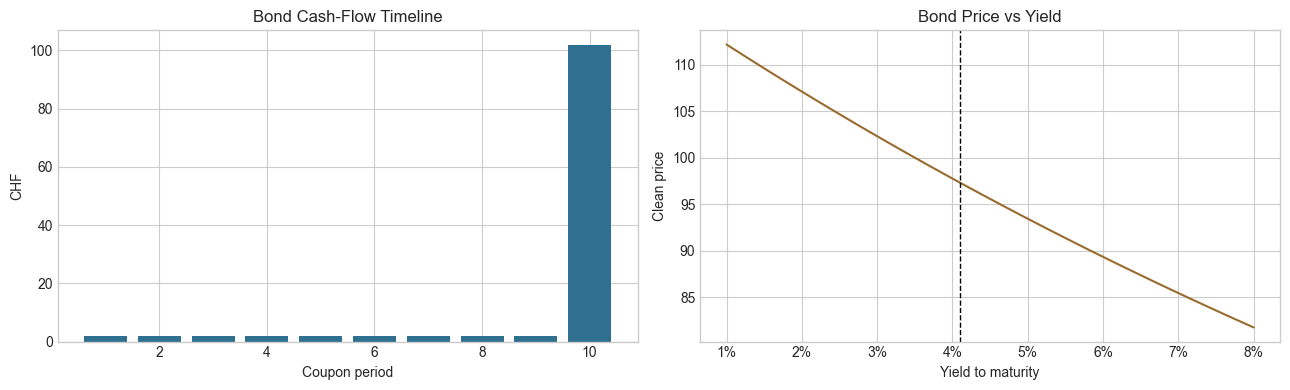

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(bond_cash_flows["period"], bond_cash_flows["cash_flow"], color="#2f6f8f")
axes[0].set_title("Bond Cash-Flow Timeline")
axes[0].set_xlabel("Coupon period")
axes[0].set_ylabel("CHF")

yield_range = np.linspace(0.01, 0.08, 60)
prices = [
    price_fixed_coupon_bond(face_value, coupon_rate, y, years_to_maturity, coupon_frequency)
    for y in yield_range
]

axes[1].plot(yield_range, prices, color="#9a6b2f")
axes[1].axvline(yield_to_maturity, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Bond Price vs Yield")
axes[1].set_xlabel("Yield to maturity")
axes[1].set_ylabel("Clean price")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

plt.tight_layout()
plt.show()

## 5. Application

Bond pricing connects debt instrument terms to market valuation:

- Coupon rate determines the contractual interest payments.
- Yield reflects the market return required for the bond's risk, maturity, and liquidity.
- Clean price is the quoted price investors usually see.
- Dirty price is the settlement amount because it includes accrued interest.
- Accrued interest prevents the buyer from receiving a full next coupon without compensating the seller for the coupon period already earned.
- Duration approximates how sensitive the bond price is to changes in yield.
- Credit spread helps compare risky bonds with safer government or swap reference rates.

In [14]:
bond_parameters = pd.DataFrame({
    "parameter": [
        "Face value",
        "Coupon rate",
        "Coupon frequency",
        "Years to maturity",
        "Yield to maturity",
        "Clean price",
        "Accrued interest",
        "Dirty price",
        "Modified duration",
    ],
    "interpretation": [
        "Principal repaid at maturity",
        "Annual coupon as a percentage of face value",
        "Number of coupon payments per year",
        "Remaining life of the bond",
        "Market discount rate implied by price and cash flows",
        "Quoted price excluding accrued interest",
        "Interest earned since the last coupon date",
        "Settlement price including accrued interest",
        "Approximate price sensitivity to yield changes",
    ],
    "example_value": [
        f"CHF {face_value:,.2f}",
        f"{coupon_rate:.2%}",
        f"{coupon_frequency}x per year",
        f"{years_to_maturity} years",
        f"{yield_to_maturity:.2%}",
        f"CHF {clean_price:,.2f}",
        f"CHF {accrued_interest:,.2f}",
        f"CHF {dirty_price:,.2f}",
        f"{modified_duration:.2f}",
    ],
})

bond_parameters

,parameter,interpretation,example_value
0,Face value,Principal repaid at maturity,CHF 100.00
1,Coupon rate,Annual coupon as a percentage of face value,3.50%
2,Coupon frequency,Number of coupon payments per year,2x per year
3,Years to maturity,Remaining life of the bond,5 years
4,Yield to maturity,Market discount rate implied by price and cash...,4.10%
5,Clean price,Quoted price excluding accrued interest,CHF 97.31
6,Accrued interest,Interest earned since the last coupon date,CHF 0.70
7,Dirty price,Settlement price including accrued interest,CHF 98.01
8,Modified duration,Approximate price sensitivity to yield changes,4.53


## 6. Reflection

- A bond is valued as the present value of promised future cash flows.
- Yield is the discount rate implied by the bond's price and cash flows.
- Bond prices and yields move in opposite directions.
- Clean price is the quoted price; dirty price is the settlement price.
- Accrued interest compensates the seller for coupon interest earned before settlement.
- Duration summarizes first-order price sensitivity to yield changes.

Questions to answer after running the notebook:

1. Why does a bond's price fall when its yield rises?
2. Why is the dirty price higher than the clean price between coupon dates?
3. What happens to accrued interest immediately after a coupon payment?
4. Why does duration matter when comparing two bonds with different maturities or coupon rates?